In [1]:
# Import standard libraries
import types
import os
import sys

# Import third-party libraries
import numpy as np
import pandas as pd

# Import local modules
project_root = os.path.dirname(os.path.dirname(os.getcwd()))  # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.quadratic_program import QuadraticProgram
from helper_functions import load_data_msci

In [2]:
def linearize_turnover_constraint(self, x_init: np.ndarray, to_budget=float('inf')) -> None:
    '''
    Linearize the turnover constraint in the quadratic programming problem.

    This method modifies the quadratic programming problem to include a linearized turnover constraint.

    Parameters:
    -----------
    x_init : np.ndarray
        The initial portfolio weights.
    to_budget : float, optional
        The maximum allowable turnover. Defaults to float('inf').

    Notes:
    ------
    - The method updates the problem's objective function coefficients, inequality constraints,
      equality constraints, and bounds to account for the turnover constraint.
    - The original problem data is overridden with the updated matrices and vectors.
    '''
    # Dimensions
    n = len(self.problem_data.get('q'))
    m = 0 if self.problem_data.get('G') is None else self.problem_data.get('G').shape[0]

    x_init = np.asarray(x_init).reshape(n)

    # Update the coefficients of the objective function
    P_old = self.problem_data.get('P')
    q_old = self.problem_data.get('q')

    P = np.block([
        [P_old, np.zeros((n, n))],
        [np.zeros((n, n)), np.zeros((n, n))]
    ])
    q = np.concatenate([q_old, np.zeros(n)])

    # Update the equality constraints
    A_old = self.problem_data.get('A')
    A = None if A_old is None else np.hstack([A_old, np.zeros((A_old.shape[0], n))])

    # Update the inequality constraints
    G_old = self.problem_data.get('G')
    h_old = self.problem_data.get('h')

    G_turn = np.vstack([
        np.hstack([ np.eye(n), -np.eye(n)]),
        np.hstack([-np.eye(n), -np.eye(n)]),
        np.hstack([np.zeros((1, n)), np.ones((1, n))])
    ])
    h_turn = np.concatenate([
        x_init,
        -x_init,
        np.array([to_budget])
    ])

    if G_old is None:
        G = G_turn
        h = h_turn
    else:
        G = np.vstack([
            np.hstack([G_old, np.zeros((m, n))]),
            G_turn
        ])
        h = np.concatenate([h_old, h_turn])

    # Update lower and upper bounds
    lb_old = self.problem_data.get('lb')
    ub_old = self.problem_data.get('ub')

    lb = np.concatenate([lb_old, np.zeros(n)])
    ub = np.concatenate([ub_old, np.repeat(np.inf, n)])

    # Override the original matrices
    self.update_problem_data({
        'P': P,
        'q': q,
        'G': G,
        'h': h,
        'A': A,
        'lb': lb,
        'ub': ub,
    })

    return None


# Load the MSCI country index data
N = 10
data = load_data_msci(path='../data/', n=N)
X = data['return_series']

# Compute expected returns and covariance
q = ExpectedReturn(method='geometric').estimate(X=X, inplace=False)
P = Covariance(method='pearson').estimate(X=X, inplace=False)

# Create constraints
constraints = Constraints(ids=X.columns.tolist())
constraints.add_budget(rhs=1, sense='=')
constraints.add_box(lower=0.0, upper=1.0)
GhAb = constraints.to_GhAb()

# Create the quadratic program
qp = QuadraticProgram(
    P=P.to_numpy(),
    q=q.to_numpy() * 0,
    G=GhAb['G'],
    h=GhAb['h'],
    A=GhAb['A'],
    b=GhAb['b'],
    lb=constraints.box['lower'].to_numpy(),
    ub=constraints.box['upper'].to_numpy(),
    solver='cvxopt',
)

# Add the method to the instance
qp.linearize_turnover_constraint = types.MethodType(linearize_turnover_constraint, qp)

# Initial portfolio
x_init = pd.Series([1 / X.shape[1]] * X.shape[1], index=X.columns)

# Add turnover constraint
qp.linearize_turnover_constraint(x_init=x_init, to_budget=0.5)

# Solve
qp.solve()

# Check turnover
solution = qp.results.get('solution')
weights = pd.Series(solution.x[:len(constraints.ids)], index=constraints.ids)

print("Turnover:")
print(np.abs(weights - x_init).sum())

Turnover:
0.49954552248142026


### Appendix for 1.)

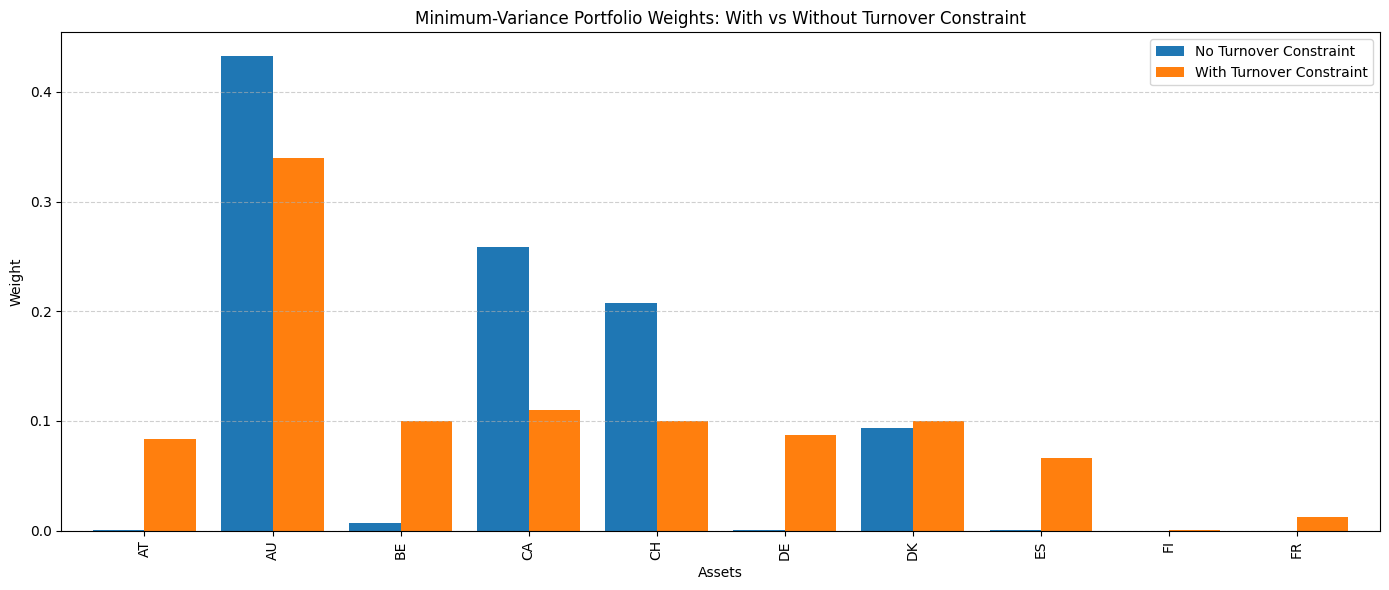


Weight comparison:
    No Turnover Constraint  With Turnover Constraint
AT                0.000268                  0.083745
AU                0.432613                  0.339312
BE                0.007045                  0.099931
CA                0.258765                  0.110309
CH                0.207532                  0.100086
DE                0.000102                  0.087477
DK                0.093368                  0.100066
ES                0.000175                  0.066566
FI                0.000047                  0.000339
FR                0.000085                  0.012170

Summary comparison:
            No Turnover Constraint  With Turnover Constraint
Turnover                  1.197821                  0.499546
Variance                  0.000064                  0.000078
Volatility                0.008005                  0.008833


In [3]:
import matplotlib.pyplot as plt

# Solve the same problem without turnover constraint
qp_no_to = QuadraticProgram(
    P=P.to_numpy(),
    q=q.to_numpy() * 0,
    G=GhAb['G'],
    h=GhAb['h'],
    A=GhAb['A'],
    b=GhAb['b'],
    lb=constraints.box['lower'].to_numpy(),
    ub=constraints.box['upper'].to_numpy(),
    solver='cvxopt',
)

qp_no_to.solve()
solution_no_to = qp_no_to.results.get('solution')
weights_no_to = pd.Series(solution_no_to.x, index=constraints.ids, name='No Turnover Constraint')

# Extract turnover-constrained weights
solution_to = qp.results.get('solution')
weights_to = pd.Series(solution_to.x[:len(constraints.ids)], index=constraints.ids, name='With Turnover Constraint')

# Compute turnover
turnover_no_to = np.abs(weights_no_to - x_init).sum()
turnover_to = np.abs(weights_to - x_init).sum()

# Compute risk
Sigma = P.to_numpy()
var_no_to = weights_no_to.to_numpy() @ Sigma @ weights_no_to.to_numpy()
var_to = weights_to.to_numpy() @ Sigma @ weights_to.to_numpy()

risk_no_to = np.sqrt(var_no_to)
risk_to = np.sqrt(var_to)

# Compare weights
comparison_df = pd.DataFrame({
    'No Turnover Constraint': weights_no_to,
    'With Turnover Constraint': weights_to
})

plt.figure(figsize=(14, 6))
comparison_df.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Minimum-Variance Portfolio Weights: With vs Without Turnover Constraint')
plt.xlabel('Assets')
plt.ylabel('Weight')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'No Turnover Constraint': [turnover_no_to, var_no_to, risk_no_to],
    'With Turnover Constraint': [turnover_to, var_to, risk_to]
}, index=['Turnover', 'Variance', 'Volatility'])

print("\nWeight comparison:")
print(comparison_df)

print("\nSummary comparison:")
print(summary_df)